In [ ]:
from rdkit import Chem
import os
import glob
import cirpy
from tqdm import tqdm
import pubchempy as pcp

run_no = 3

dirs = glob.glob(f"2D_mols/run_{run_no}/*/")
cas = [d.split("/")[-2].split()[0] for d in dirs]

for cas_no, d in tqdm(zip(cas, dirs), total=len(cas)):
    if os.path.exists(f"{os.path.join(d, cas_no)}.mol"):
        continue
    smiles = cirpy.resolve(cas_no, 'smiles')
    if smiles is None:
        pcp_compound = pcp.get_compounds(cas_no, 'name')
        if pcp_compound:
            smiles = pcp_compound[0].connectivity_smiles
            
    if smiles is None:
        print(f"Could not resolve SMILES for CAS {cas_no}")
        continue

    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    if mol is None:
        continue
    
    
    # print(f"{os.path.join(d, cas_no)}.mol")
    Chem.MolToMolFile(mol, f"{os.path.join(d, cas_no)}.mol")

  7%|▋         | 3/46 [00:01<00:16,  2.65it/s]

Could not resolve SMILES for CAS 2024-35-5


 39%|███▉      | 18/46 [00:06<00:08,  3.12it/s]

Could not resolve SMILES for CAS (1654)


 46%|████▌     | 21/46 [00:06<00:07,  3.15it/s]

...

 87%|████████▋ | 40/46 [00:14<00:02,  2.69it/s]

Could not resolve SMILES for CAS (699)


 91%|█████████▏| 42/46 [00:16<00:02,  1.91it/s]

Could not resolve SMILES for CAS (216)


100%|██████████| 46/46 [00:18<00:00,  2.55it/s]


In [12]:

all_mols = []
sps_scores = []

In [ ]:
## Mols so far

from rdkit import Chem
import os
import glob
import cirpy
from rdkit.Chem import SpacialScore
from tqdm import tqdm
import pubchempy as pcp
import pandas as pd


dirs = glob.glob(f"2D_mols/run_{run_no}/*/")
cas = [d.split("/")[-2].split()[0] for d in dirs]
ids = [d.split("/")[-2].split()[-1].split('(')[-1].split(')')[0] for d in dirs]
df = pd.read_excel(f"/Users/mx23826/Downloads/cheminventory_09_04_2026/sampled/sampled_df_run_{run_no}.xlsx")

# for cas_no, d in tqdm(zip(cas, dirs), total=len(cas)):
    # smiles = cirpy.resolve(cas_no, 'smiles')
    # if smiles is None:
    #     pcp_compound = pcp.get_compounds(cas_no, 'name')
    #     if pcp_compound:
    #         smiles = pcp_compound[0].connectivity_smiles
            
    # if smiles is None:
    #     print(f"Could not resolve SMILES for CAS {cas_no}")
    #     continue

    # mol = Chem.MolFromSmiles(smiles)
    # if mol is None:
    #     continue
    
for id in tqdm(ids, total=len(ids)):
    mol = Chem.MolFromSmiles(df[df['index'] == int(id)]['SMILES'].values[0])
    if mol is None:
        continue
    # print(f"{os.path.join(d, cas_no)}.mol")
    all_mols.append(mol)
    sps_score = SpacialScore.SPS(mol)
    sps_scores.append(sps_score)
    

100%|██████████| 46/46 [00:00<00:00, 928.71it/s]


In [14]:
df = pd.DataFrame({
    "mol": all_mols,
    "sps_score": sps_scores,
    'SMILES': [Chem.MolToSmiles(mol) for mol in all_mols]
})

In [15]:
# from rdkit.Chem import Draw

# Draw.MolsToGridImage(all_mols, molsPerRow=8, subImgSize=(400, 400), useSVG=True)

import mols2grid

mols2grid.display(df, n_cols=12, size=(260, 180), n_items_per_page=120, subset=['sps_score'])

MolGridWidget()

In [16]:
df['sps_score'].mean()

22.036928889235842

(array([5., 5., 6., 0., 2., 7., 2., 6., 2., 1., 1., 2., 3., 1., 1., 0., 0.,
        0., 0., 2.]),
 array([ 6. ,  7.7,  9.4, 11.1, 12.8, 14.5, 16.2, 17.9, 19.6, 21.3, 23. ,
        24.7, 26.4, 28.1, 29.8, 31.5, 33.2, 34.9, 36.6, 38.3, 40. ]),
 <BarContainer object of 20 artists>)

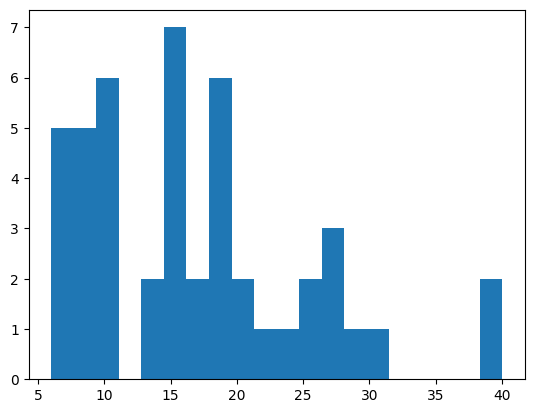

In [17]:
import matplotlib.pyplot as plt

nium_heavy_atoms = [mol.GetNumHeavyAtoms() for mol in all_mols]
plt.hist(nium_heavy_atoms, bins=20)

(array([2., 1., 3., 2., 4., 3., 2., 2., 3., 5., 1., 0., 7., 2., 2., 0., 2.,
        3., 1., 1.]),
 array([15.33333333, 16.05238095, 16.77142857, 17.49047619, 18.20952381,
        18.92857143, 19.64761905, 20.36666667, 21.08571429, 21.8047619 ,
        22.52380952, 23.24285714, 23.96190476, 24.68095238, 25.4       ,
        26.11904762, 26.83809524, 27.55714286, 28.27619048, 28.9952381 ,
        29.71428571]),
 <BarContainer object of 20 artists>)

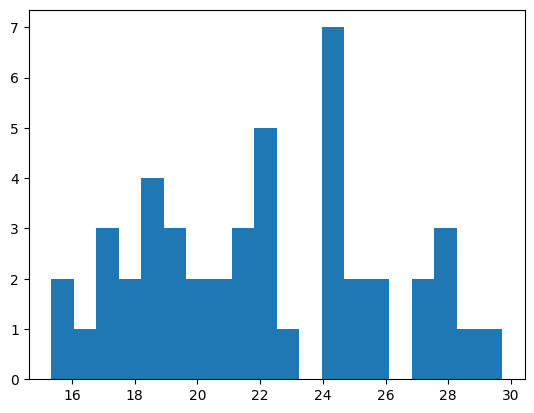

In [18]:
plt.hist(sps_scores, bins=20)

In [25]:
# Make .mol for mols without cas
mol = Chem.AddHs(Chem.MolFromSmiles('[H]c1c([H])c([H])c(C([H])(B2OC(C([H])([H])[H])(C([H])([H])[H])C(C([H])([H])[H])(C([H])([H])[H])O2)C([H])([H])B2OC(C([H])([H])[H])(C([H])([H])[H])C(C([H])([H])[H])(C([H])([H])[H])O2)c([H])c1[H]'))
Chem.MolToMolFile(mol, f"2D_mols/run_{run_no}/(453)/(453).mol")


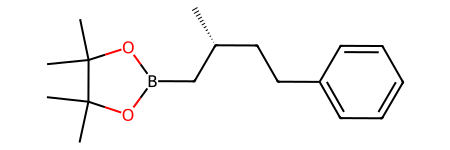

In [20]:
mol